# 05 — LLM-Pipeline 2: Visualisierungen → natürlichsprachliche Erklärung

**Idee:** Das LLM erhält **Waterfall-Plots** der SHAP-/EBM-Beiträge als Bild
und erklärt, was es sieht — ohne strukturierte JSON-Daten.

- **Vorteil:** Nutzt visuelle Mustererkennung; näher an menschlicher Intuition.
- **Nachteil:** Präzise Zahlenwerte gehen im Bild verloren.

**Ablauf:**
1. Plots generieren und in `explanations/plots/` speichern (kein API-Key nötig)
2. Plots + Kontext-Prompt an Claude senden
3. Ergebnisse in `results/pipeline05/` speichern

In [1]:
from __future__ import annotations

import sys, json, time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import joblib
import shap

from utils import INSTANCE_IDS, EXPLANATIONS_DIR, RESULTS_DIR, MODELS_DIR, PROMPTS_DIR
from utils.data import load_train_test
from utils.llm import ask_with_images, DEFAULT_MODEL, MAX_TOKENS_GENERATION, strip_scratchpad

LOSS_KEY  = 'poisson_log'
MODEL     = DEFAULT_MODEL
MAX_TOKENS = MAX_TOKENS_GENERATION  # B6: angehoben (Scratchpad-Overhead)
PLOTS_DIR = EXPLANATIONS_DIR / 'plots'
OUT_DIR   = RESULTS_DIR / 'pipeline05'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'LLM-Modell:    {MODEL}')
print(f'Plots-Ausgabe: {PLOTS_DIR}')
print(f'Ergebnisse:    {OUT_DIR}')

LLM-Modell:    claude-sonnet-4-6
Plots-Ausgabe: /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation_XAI_Stahl_SoSe26/explanations/plots
Ergebnisse:    /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation_XAI_Stahl_SoSe26/results/pipeline05


## 1 · Daten und Modelle laden

In [2]:
X_train, y_train, X_test, y_test = load_train_test()
from utils.models import load_models
xgb, ebm = load_models(LOSS_KEY)

# SHAP TreeExplainer einmal initialisieren (teuer)
shap_explainer = shap.TreeExplainer(xgb)
shap_values    = shap_explainer(X_test)

print('Modelle und SHAP-Werte geladen.')
print(f'X_test shape: {X_test.shape}')

Modelle und SHAP-Werte geladen.
X_test shape: (5227, 9)


## 2 · Plot-Generierung

Für jede Instanz und jedes Modell wird ein Waterfall-Plot erzeugt:
- **XGBoost**: `shap.plots.waterfall` (eingebaut)
- **EBM**: Matplotlib-Balkendiagramm (interpret nutzt Plotly, nicht Matplotlib)

In [3]:
def plot_xgb_waterfall(instance_id: int) -> Path:
    """SHAP Waterfall-Plot für XGBoost, gespeichert als PNG."""
    pos  = X_test.index.get_loc(instance_id)
    pred = float(xgb.predict(X_test.iloc[[pos]])[0])
    y    = float(y_test.iloc[pos])

    shap.plots.waterfall(shap_values[pos], show=False, max_display=10)
    plt.title(f'XGBoost – Instanz {instance_id} | '
              f'Vorhersage: {pred:.1f}  (tatsächlich: {y:.0f})', pad=12)
    path = PLOTS_DIR / f'waterfall_xgb_{LOSS_KEY}_inst{instance_id}.png'
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.close('all')
    return path


def plot_ebm_waterfall(instance_id: int) -> Path:
    """Manueller Waterfall-Plot für EBM-Beiträge."""
    pos  = X_test.index.get_loc(instance_id)
    inst = X_test.iloc[[pos]]
    pred = float(ebm.predict(inst)[0])
    y    = float(y_test.iloc[pos])

    exp  = ebm.explain_local(inst)
    d    = exp.data(0)
    base = float(d['extra']['scores'][0])  # Intercept

    # Nur Haupteffekte (keine Interaktionen), Top-10 nach |score|
    pairs = [(n, float(s)) for n, s in zip(d['names'], d['scores'])]
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:10]
    labels = [p[0] for p in pairs]
    scores = [p[1] for p in pairs]
    colors = ['#d73027' if v > 0 else '#4575b4' for v in scores]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1], height=0.65)
    ax.axvline(0, color='black', lw=0.8)
    for bar, val in zip(bars, scores[::-1]):
        ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    ax.set_xlabel('Beitrag (Log-Skala)', fontsize=10)
    ax.set_title(f'EBM – Instanz {instance_id} | '
                 f'Vorhersage: {pred:.1f}  (tatsächlich: {y:.0f})\n'
                 f'Basiswert (Intercept): {base:.3f}', fontsize=11, pad=12)
    plt.tight_layout()
    path = PLOTS_DIR / f'waterfall_ebm_{LOSS_KEY}_inst{instance_id}.png'
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.close('all')
    return path

In [4]:
plot_paths: dict[tuple, Path] = {}

for iid in INSTANCE_IDS:
    p_xgb = plot_xgb_waterfall(iid)
    p_ebm = plot_ebm_waterfall(iid)
    plot_paths[('xgb', iid)] = p_xgb
    plot_paths[('ebm', iid)] = p_ebm
    print(f'  inst={iid:4d}  -> {p_xgb.name}')
    print(f'         -> {p_ebm.name}')

print(f'\n{len(plot_paths)} Plots gespeichert in {PLOTS_DIR}')

  inst= 224  -> waterfall_xgb_poisson_log_inst224.png
         -> waterfall_ebm_poisson_log_inst224.png
  inst= 580  -> waterfall_xgb_poisson_log_inst580.png
         -> waterfall_ebm_poisson_log_inst580.png
  inst=1041  -> waterfall_xgb_poisson_log_inst1041.png
         -> waterfall_ebm_poisson_log_inst1041.png
  inst=1481  -> waterfall_xgb_poisson_log_inst1481.png
         -> waterfall_ebm_poisson_log_inst1481.png
  inst=1677  -> waterfall_xgb_poisson_log_inst1677.png
         -> waterfall_ebm_poisson_log_inst1677.png
  inst=2058  -> waterfall_xgb_poisson_log_inst2058.png
         -> waterfall_ebm_poisson_log_inst2058.png
  inst=2510  -> waterfall_xgb_poisson_log_inst2510.png
         -> waterfall_ebm_poisson_log_inst2510.png
  inst=3543  -> waterfall_xgb_poisson_log_inst3543.png
         -> waterfall_ebm_poisson_log_inst3543.png
  inst=3847  -> waterfall_xgb_poisson_log_inst3847.png
         -> waterfall_ebm_poisson_log_inst3847.png
  inst=4454  -> waterfall_xgb_poisson_log_inst4454

## 3 · Beispielplots anzeigen

XGB – Instanz 224:


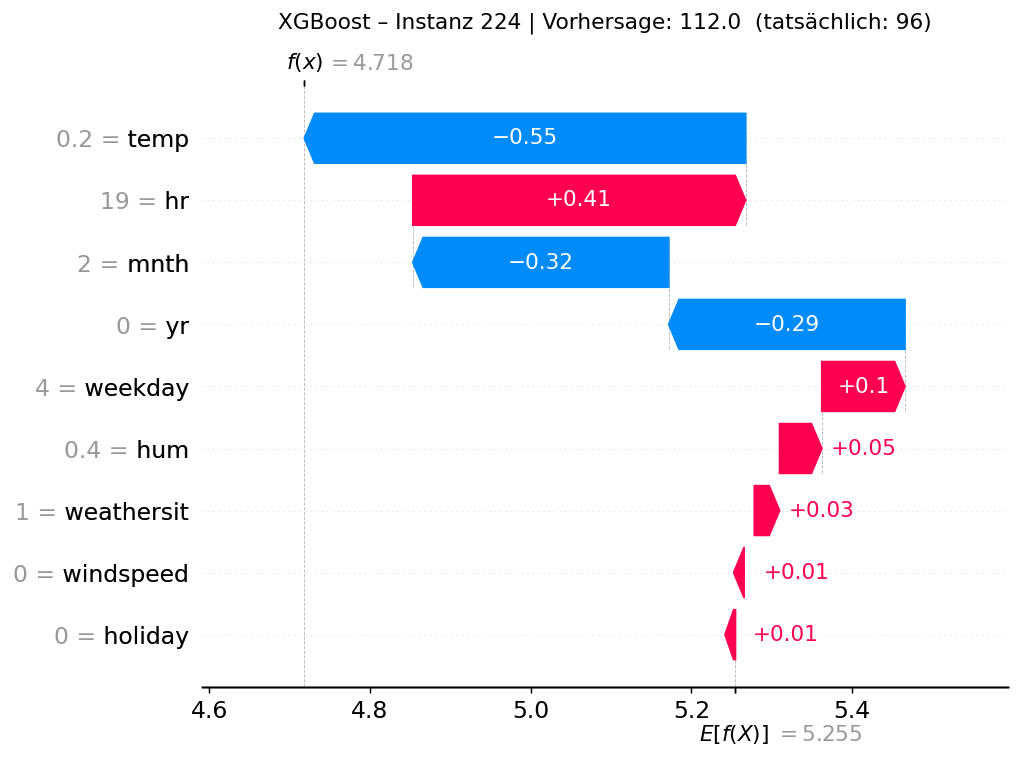


EBM – Instanz 224:


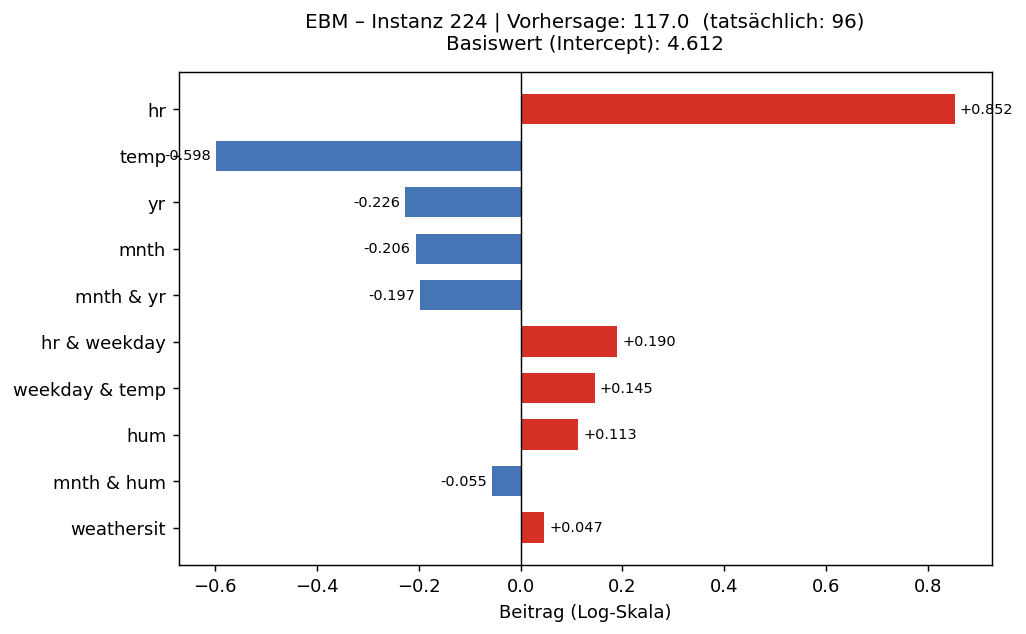

In [5]:
from IPython.display import display, Image as IPImage

for model_name in ['xgb', 'ebm']:
    iid = INSTANCE_IDS[0]
    print(f'{model_name.upper()} – Instanz {iid}:')
    display(IPImage(filename=str(plot_paths[(model_name, iid)]), width=620))
    print()

## 4 · System-Prompt

In [6]:
SYSTEM_PROMPT = (PROMPTS_DIR / "pipeline_05_vision.md").read_text()

print(f'System-Prompt: {len(SYSTEM_PROMPT)} Zeichen, ~{len(SYSTEM_PROMPT)//4} Tokens (geschätzt)')

System-Prompt: 2386 Zeichen, ~596 Tokens (geschätzt)


## 5 · LLM-Aufrufe mit Plots

> **Voraussetzung:** `ANTHROPIC_API_KEY` in `.env` oder als Umgebungsvariable.

In [7]:
from utils.explanations import (
    WEEKDAY_NAMES, MONTH_NAMES, WEATHER_NAMES,
    TEMP_FACTOR, HUM_FACTOR, WIND_FACTOR,
)


def build_context_prompt(model_name: str, instance_id: int) -> str:
    """Kontexttext zum Plot — lesbare Merkmalswerte aus JSON-Erklärung."""
    local_path = EXPLANATIONS_DIR / f'local_{model_name}_{LOSS_KEY}_inst{instance_id}.json'
    l = json.loads(local_path.read_text())
    fv = l["feature_values"]

    lines = [
        f"Modell: {model_name.upper()}",
        f"Instanz-ID: {instance_id}",
        f"Uhrzeit: {int(fv['hr']):02d}:00 Uhr",
        f"Wochentag: {WEEKDAY_NAMES[int(fv['weekday'])]}",
        f"Monat: {MONTH_NAMES[int(fv['mnth'])]}",
        f"Jahr: {'2011' if int(fv['yr']) == 0 else '2012'}",
        f"Wetter: {WEATHER_NAMES.get(int(fv['weathersit']), str(fv['weathersit']))}",
        f"Temperatur: ~{float(fv['temp']) * TEMP_FACTOR:.1f} °C (normalisiert: {float(fv['temp']):.2f})",
        f"Luftfeuchtigkeit: {float(fv['hum']) * HUM_FACTOR:.0f} %",
        f"Windgeschwindigkeit: {float(fv['windspeed']) * WIND_FACTOR:.1f} km/h",
        f"Feiertag: {'ja' if int(fv['holiday']) == 1 else 'nein'}",
        f"Tatsächliche Ausleihe: {int(l['y_true'])} Fahrräder",
        f"Modellvorhersage: {l['prediction']:.1f} Fahrräder",
        "",
        "Bitte erkläre den Waterfall-Plot oben für diese Situation.",
    ]
    return "\n".join(lines)

results = []
total_in, total_out, total_cache = 0, 0, 0

for model_name in ["xgb", "ebm"]:
    for iid in INSTANCE_IDS:
        out_file = OUT_DIR / f"{model_name}_inst{iid}.json"
        if out_file.exists():
            results.append(json.loads(out_file.read_text()))
            print(f"  {model_name.upper()} inst={iid:4d}  [übersprungen – bereits vorhanden]")
            continue

        prompt = build_context_prompt(model_name, iid)
        plot_path = plot_paths[(model_name, iid)]

        t0 = time.time()
        response = ask_with_images(
            prompt,
            image_paths=[plot_path],
            system=SYSTEM_PROMPT,
            model=MODEL,
            max_tokens=MAX_TOKENS,
            cache_system=True,
        )
        elapsed = time.time() - t0

        text    = strip_scratchpad(response["content"][0]["text"])
        usage   = response.get("usage", {})
        in_tok  = usage.get("input_tokens", 0)
        out_tok = usage.get("output_tokens", 0)
        cache_r = usage.get("cache_read_input_tokens", 0)
        total_in += in_tok; total_out += out_tok; total_cache += cache_r

        local_path = EXPLANATIONS_DIR / f"local_{model_name}_{LOSS_KEY}_inst{iid}.json"
        l = json.loads(local_path.read_text())

        record = {
            "pipeline":    "05_vision",
            "llm_model":   MODEL,
            "loss_key":    LOSS_KEY,
            "xai_model":   model_name,
            "instance_id": iid,
            "explanation": text,
            "plot_file":   plot_path.name,
            "elapsed_s":   round(elapsed, 2),
            "usage":       {"input_tokens": in_tok, "output_tokens": out_tok,
                            "cache_read_input_tokens": cache_r},
            "prediction":  l["prediction"],
            "y_true":      l["y_true"],
        }
        results.append(record)
        (OUT_DIR / f"{model_name}_inst{iid}.json").write_text(
            json.dumps(record, indent=2, ensure_ascii=False)
        )
        print(f"  {model_name.upper()} inst={iid:4d}  "
              f"pred={l['prediction']:6.1f}  y={l['y_true']:5.0f}  "
              f"in={in_tok}  out={out_tok}  cache={cache_r}  t={elapsed:.1f}s")

print(f"\nGesamt:  input={total_in}  output={total_out}  cache_gelesen={total_cache}")

  XGB inst= 224  pred= 112.0  y=   96  in=2241  out=520  cache=0  t=12.0s
  XGB inst= 580  pred=  64.6  y=   63  in=2241  out=524  cache=0  t=12.7s
  XGB inst=1041  pred= 385.4  y=  387  in=2297  out=540  cache=0  t=13.0s
  XGB inst=1481  pred= 228.6  y=  277  in=2298  out=518  cache=0  t=12.3s
  XGB inst=1677  pred= 254.3  y=  286  in=2297  out=468  cache=0  t=12.4s
  XGB inst=2058  pred= 194.1  y=  243  in=2242  out=504  cache=0  t=11.0s
  XGB inst=2510  pred= 326.0  y=  372  in=2244  out=523  cache=0  t=13.2s
  XGB inst=3543  pred= 309.9  y=  286  in=2298  out=545  cache=0  t=12.2s
  XGB inst=3847  pred= 585.8  y=  531  in=2298  out=546  cache=0  t=13.0s
  XGB inst=4454  pred= 297.3  y=  354  in=2297  out=532  cache=0  t=11.6s
  EBM inst= 224  pred= 117.0  y=   96  in=2057  out=520  cache=0  t=11.7s
  EBM inst= 580  pred=  73.1  y=   63  in=2057  out=540  cache=0  t=13.5s
  EBM inst=1041  pred= 389.7  y=  387  in=2057  out=535  cache=0  t=11.0s
  EBM inst=1481  pred= 241.8  y=  277 

## 6 · Beispiel-Erklärungen

In [8]:
for rec in results[:2]:
    sep = '=' * 70
    print(sep)
    print(f"Modell: {rec['xai_model'].upper()}  |  Instanz: {rec['instance_id']}  "
          f"|  Plot: {rec['plot_file']}")
    print(f"Vorhersage: {rec['prediction']:.1f}  |  Tatsächlich: {rec['y_true']:.0f}")
    print(sep)
    print(rec['explanation'])
    print()

Modell: XGB  |  Instanz: 224  |  Plot: waterfall_xgb_poisson_log_inst224.png
Vorhersage: 112.0  |  Tatsächlich: 96
Das Modell sagt für diese Stunde 112 Ausleihen vorher, tatsächlich wurden 96 Fahrräder ausgeliehen. Die Abweichung von 16 Rädern entspricht etwa 17 % — das ist eine mäßige Schätzung: die Größenordnung stimmt, aber das Modell überschätzt die Nachfrage spürbar.

Den stärksten Einfluss hat die Temperatur von nur etwa 8 °C: Dieser Wert liegt deutlich unter dem, was Radfahrer als angenehm empfinden, und drückt die Vorhersage kräftig nach unten. Ohne diesen Kälteeffekt wäre die vorhergesagte Zahl noch deutlich höher ausgefallen. Gegenläufig wirkt die Abendstunde 19 Uhr: Der Feierabendverkehr ist der zweitstärkste Treiber und hebt die Nachfrage erheblich an, da viele Berufspendler jetzt nach Hause fahren. Drittens zieht der Monat Februar die Vorhersage ebenfalls nach unten — der Februar gilt systemweit als ruhiger Wintermonat mit generell weniger Ausleihaktivität. Zusätzlich dämp

## 7 · Zusammenfassung

In [9]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Modell':     r['xai_model'].upper(),
        'Instanz':    r['instance_id'],
        'y_true':     r['y_true'],
        'Vorhersage': r['prediction'],
        'Wörter':     len(r['explanation'].split()),
        'tok_input':  r['usage']['input_tokens'],
        'tok_output': r['usage']['output_tokens'],
        'Zeit (s)':   r['elapsed_s'],
    }
    for r in results
])
display(summary)

,Modell,Instanz,y_true,Vorhersage,Wörter,tok_input,tok_output,Zeit (s)
0,XGB,224,96.0,111.9967,203,2241,520,11.99
1,XGB,580,63.0,64.5773,213,2241,524,12.66
2,XGB,1041,387.0,385.3899,222,2297,540,13.01
3,XGB,1481,277.0,228.5813,208,2298,518,12.26
4,XGB,1677,286.0,254.2623,191,2297,468,12.39
5,XGB,2058,243.0,194.0592,198,2242,504,10.97
6,XGB,2510,372.0,326.0351,215,2244,523,13.19
7,XGB,3543,286.0,309.9225,220,2298,545,12.16
8,XGB,3847,531.0,585.7666,223,2298,546,12.99
9,XGB,4454,354.0,297.3312,222,2297,532,11.58
